In [1]:
# Cell 0 — Imports + display
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

Ensure to run file "RF_Initial_Feature_Engineering.py" in path 2b_feature_engineering prior to this notebook to populate featureset.

In [2]:
# Cell 1 — Paths 
from pathlib import Path

DATA_DIR = Path("1_download_data/model_ready")
DATA_FILE = DATA_DIR / "flights_model_ready.parquet"

print("Reading:", DATA_FILE)

Reading: /home/zranjbar/teams/z6/data/model_ready/flights_model_ready.parquet


In [4]:
# Cell 2 — Load ONLY the columns we need (saves RAM)
# NOTE: If a column doesn't exist in your parquet, we’ll drop it safely after reading.
wanted_cols = [
    "FlightDate", "target",
    "Airline", "Origin", "Dest",
    "DepTimeBlk", "CRSDepTime", "dep_hour",
    "Month", "DayOfWeek", "DayofMonth", "Quarter",
    "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "gust", "p01i", "relh",
    "OriginState"  # only used if present (for region cap)
]

df = pd.read_parquet(DATA_FILE, columns=wanted_cols)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

# Ensure datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
df = df.dropna(subset=["FlightDate", "target"]).reset_index(drop=True)

display(df.head(3))

Loaded shape: (14539250, 21)
Columns: ['FlightDate', 'target', 'Airline', 'Origin', 'Dest', 'DepTimeBlk', 'CRSDepTime', 'dep_hour', 'Month', 'DayOfWeek', 'DayofMonth', 'Quarter', 'Distance', 'DistanceGroup', 'tmpf', 'vsby', 'sknt', 'gust', 'p01i', 'relh', 'OriginState']


,FlightDate,target,Airline,Origin,Dest,DepTimeBlk,CRSDepTime,dep_hour,Month,DayOfWeek,DayofMonth,Quarter,Distance,DistanceGroup,tmpf,vsby,sknt,gust,p01i,relh,OriginState
0,2018-01-03,Delayed,Endeavor Air Inc.,ATL,ABY,1000-1059,1037,10,1,Wednesday,3,1,145.0,1,27.0,10.0,6.000000,0.0,0.0,40.42,GA
1,2018-01-04,On time,Endeavor Air Inc.,ATL,ABY,1000-1059,1037,10,1,Thursday,4,1,145.0,1,24.1,10.0,14.166667,21.0,0.0,54.36,GA
2,2018-01-05,On time,Endeavor Air Inc.,ATL,ABY,1000-1059,1037,10,1,Friday,5,1,145.0,1,17.1,10.0,12.153846,0.0,0.0,55.51,GA


In [6]:
# Cell 3 — Sampling strategy 
def sample_multistage(
    df: pd.DataFrame,
    total_sample: int = 700_000,
    max_origin_frac: float = 0.05,
    max_region_frac: float = 0.30,
    random_state: int = 42,
    target_col: str = "target",
):
    df = df.copy()

    # month column
    df["month"] = df["FlightDate"].dt.to_period("M").astype(str)

    # STEP 1: Balance months
    n_months = df["month"].nunique()
    rows_per_month = max(1, total_sample // max(1, n_months))

    month_samples = []
    for _, g in df.groupby("month"):
        month_samples.append(g.sample(n=min(len(g), rows_per_month), random_state=random_state))
    month_balanced = pd.concat(month_samples, ignore_index=True)
    print("After month balancing:", month_balanced.shape)

    # STEP 2: Cap Origin dominance (if Origin exists)
    if "Origin" in month_balanced.columns:
        origin_cap = int(len(month_balanced) * max_origin_frac)
        origin_balanced = (
            month_balanced
            .groupby("Origin", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), origin_cap), random_state=random_state))
        )
    else:
        origin_balanced = month_balanced.copy()
    print("After origin cap:", origin_balanced.shape)

    # STEP 2.5: Cap Region dominance (if OriginState exists)
    if "OriginState" in origin_balanced.columns:
        state_to_region = {
            "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
            "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
            "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
            "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
            "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
            "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",
            "DE": "South", "FL": "South", "GA": "South", "MD": "South",
            "NC": "South", "SC": "South", "VA": "South", "WV": "South",
            "AL": "South", "KY": "South", "MS": "South", "TN": "South",
            "AR": "South", "LA": "South", "OK": "South", "TX": "South",
            "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
            "NV": "West", "NM": "West", "UT": "West", "WY": "West",
            "AK": "West", "CA": "West", "HI": "West", "OR": "West",
            "WA": "West"
        }
        origin_balanced["OriginState"] = origin_balanced["OriginState"].astype(str).str.upper()
        origin_balanced["OriginRegion"] = origin_balanced["OriginState"].map(state_to_region)

        region_cap = int(len(origin_balanced) * max_region_frac)
        region_balanced = (
            origin_balanced
            .groupby("OriginRegion", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), region_cap), random_state=random_state))
        )
    else:
        region_balanced = origin_balanced.copy()
    print("After region cap:", region_balanced.shape)

    # STEP 3: Stratify by target (best effort)
    n_classes = region_balanced[target_col].nunique()
    rows_per_class = len(region_balanced) // max(1, n_classes)

    final_sample = (
        region_balanced
        .groupby(target_col, group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), rows_per_class), random_state=random_state))
        .reset_index(drop=True)
    )
    print("FINAL SAMPLE rows:", len(final_sample))

    return final_sample

In [7]:
# Cell 4 — Run sampling + quick checks
final_sample = sample_multistage(
    df,
    total_sample=700_000,
    max_origin_frac=0.05,
    max_region_frac=0.30,
    random_state=42,
    target_col="target",
)

print("\nTarget distribution (final_sample):")
display(final_sample["target"].value_counts(normalize=True))

print("\nTop origins (final_sample):")
if "Origin" in final_sample.columns:
    display(final_sample["Origin"].value_counts(normalize=True).head(10))

print("\nMonth distribution (final_sample):")
display(final_sample["month"].value_counts(normalize=True).sort_index().head(20))

After month balancing: (699997, 22)


/tmp/ipykernel_758/1728636597.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), origin_cap), random_state=random_state))


After origin cap: (649287, 22)


/tmp/ipykernel_758/1728636597.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), region_cap), random_state=random_state))


After region cap: (576598, 23)


...

target
On time      0.611869
Delayed      0.352409
Cancelled    0.035722
Name: proportion, dtype: float64


Top origins (final_sample):


Origin
ORD    0.061668
DEN    0.057278
LAX    0.051942
DFW    0.048787
ATL    0.045362
EWR    0.045270
LAS    0.042821
CLT    0.042595
SEA    0.041204
PHX    0.040657
Name: proportion, dtype: float64


Month distribution (final_sample):


month
2018-01    0.023698
2018-02    0.023895
2018-03    0.023739
2018-04    0.022950
2018-05    0.024058
2018-06    0.024462
2018-07    0.024529
2018-08    0.024227
2018-09    0.022332
2018-10    0.022434
2018-11    0.023310
2018-12    0.022781
2019-01    0.023116
2019-02    0.024227
2019-03    0.023010
2019-04    0.023189
2019-05    0.023399
2019-06    0.025007
2019-07    0.024122
2019-08    0.023717
Name: proportion, dtype: float64

In [8]:
# Cell 5 — Train/Val/Test split (stratified; consistent with teammate split style)
from sklearn.model_selection import train_test_split

final_sample = final_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)  # shuffle

train_df, temp_df = train_test_split(
    final_sample,
    test_size=0.30,                      # 70% train, 30% temp
    stratify=final_sample["target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,                      # 15% val, 15% test
    stratify=temp_df["target"],
    random_state=42
)

print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("\nTrain target distribution:")
display(train_df["target"].value_counts(normalize=True))
print("\nVal target distribution:")
display(val_df["target"].value_counts(normalize=True))
print("\nTest target distribution:")
display(test_df["target"].value_counts(normalize=True))

Train/Val/Test: (219882, 23) (47118, 23) (47118, 23)

Train target distribution:


target
On time      0.611869
Delayed      0.352407
Cancelled    0.035724
Name: proportion, dtype: float64


Val target distribution:


target
On time      0.611868
Delayed      0.352413
Cancelled    0.035719
Name: proportion, dtype: float64


Test target distribution:


target
On time      0.611868
Delayed      0.352413
Cancelled    0.035719
Name: proportion, dtype: float64

In [9]:
# Cell 6 — LR feature engineering (simple + safe; no leakage features)
def add_lr_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Ensure dep_hour exists (fallback from CRSDepTime if needed)
    if "dep_hour" not in df.columns or df["dep_hour"].isna().all():
        if "CRSDepTime" in df.columns:
            # CRSDepTime often HHMM int; convert to hour
            crs = pd.to_numeric(df["CRSDepTime"], errors="coerce")
            df["dep_hour"] = (crs // 100).astype("Int64")
        else:
            df["dep_hour"] = pd.Series([pd.NA] * len(df), dtype="Int64")

    # Time-of-day flags from EDA-style ideas
    df["is_early_morning"] = df["dep_hour"].between(5, 7, inclusive="both").astype(int)
    df["is_evening"] = (df["dep_hour"] >= 18).astype(int)
    df["is_red_eye"] = (df["dep_hour"] <= 4).astype(int)

    # Cyclical encodings for DayOfWeek and Month (if numeric)
    # If DayOfWeek is 1-7 or 0-6, both work (we infer max)
    if "DayOfWeek" in df.columns:
        dow = pd.to_numeric(df["DayOfWeek"], errors="coerce")
        dow_max = 7.0 if dow.max() and dow.max() > 6 else 6.0
        df["dow_sin"] = np.sin(2 * np.pi * dow / (dow_max + 1))
        df["dow_cos"] = np.cos(2 * np.pi * dow / (dow_max + 1))

    if "Month" in df.columns:
        m = pd.to_numeric(df["Month"], errors="coerce")
        df["month_sin"] = np.sin(2 * np.pi * m / 12.0)
        df["month_cos"] = np.cos(2 * np.pi * m / 12.0)
        df["is_summer"] = m.isin([6, 7, 8]).astype(int)
        df["is_holiday_season"] = m.isin([11, 12, 1]).astype(int)

    # Weather threshold flags (if columns exist)
    if "sknt" in df.columns:
        df["high_wind"] = ((pd.to_numeric(df["sknt"], errors="coerce") > 20) |
                           (pd.to_numeric(df.get("gust", np.nan), errors="coerce") > 35)).astype(int)

    if "vsby" in df.columns:
        df["low_visibility"] = (pd.to_numeric(df["vsby"], errors="coerce") < 3).astype(int)

    if "p01i" in df.columns:
        p = pd.to_numeric(df["p01i"], errors="coerce")
        df["precip_light"] = ((p >= 0.01) & (p < 0.1)).astype(int)
        df["precip_moderate"] = ((p >= 0.1) & (p < 0.5)).astype(int)
        df["precip_heavy"] = (p >= 0.5).astype(int)

    return df

In [10]:
# Cell 7 — Apply feature engineering
train_lr = add_lr_features(train_df)
val_lr   = add_lr_features(val_df)
test_lr  = add_lr_features(test_df)

print(train_lr.shape, val_lr.shape, test_lr.shape)

(219882, 37) (47118, 37) (47118, 37)


In [11]:
# Cell 8 — Define columns for LR + preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

TARGET = "target"

# Candidate categorical features (only keep those that exist)
cat_candidates = ["Airline", "Origin", "Dest", "DepTimeBlk"]
categorical_features = [c for c in cat_candidates if c in train_lr.columns]

# Candidate numeric features (only keep those that exist)
num_candidates = [
    "dep_hour",
    "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "Distance",
    "tmpf", "vsby", "sknt", "gust", "p01i", "relh",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "is_early_morning", "is_evening", "is_red_eye",
    "is_summer", "is_holiday_season",
    "high_wind", "low_visibility",
    "precip_light", "precip_moderate", "precip_heavy"
]
numeric_features = [c for c in num_candidates if c in train_lr.columns]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", Pipeline(steps=[
            ("impute", "passthrough"),   # we’ll fill NaNs below
            ("scale", StandardScaler(with_mean=False))  # safe for sparse
        ]), numeric_features),
    ],
    remainder="drop"
)

# Fill numeric NaNs with 0 (simple baseline)
for c in numeric_features:
    train_lr[c] = pd.to_numeric(train_lr[c], errors="coerce").fillna(0)
    val_lr[c]   = pd.to_numeric(val_lr[c], errors="coerce").fillna(0)
    test_lr[c]  = pd.to_numeric(test_lr[c], errors="coerce").fillna(0)

# Fill categorical NaNs with "missing"
for c in categorical_features:
    train_lr[c] = train_lr[c].astype(str).fillna("missing")
    val_lr[c]   = val_lr[c].astype(str).fillna("missing")
    test_lr[c]  = test_lr[c].astype(str).fillna("missing")

Categorical: ['Airline', 'Origin', 'Dest', 'DepTimeBlk']
Numeric: ['dep_hour', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Distance', 'tmpf', 'vsby', 'sknt', 'gust', 'p01i', 'relh', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_early_morning', 'is_evening', 'is_red_eye', 'is_summer', 'is_holiday_season', 'high_wind', 'low_visibility', 'precip_light', 'precip_moderate', 'precip_heavy']


In [28]:
# Cell 9 — Train multinomial Logistic Regression (3 classes)
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    multi_class="multinomial",
    solver="saga",          
    penalty="l2",
    C=0.008,              
    class_weight="balanced",
    max_iter=6000,          
    tol=1e-3,               # helps convergence speed
    n_jobs=-1,
    random_state=42
)

lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("lr", lr_model)
])

lr_pipeline.fit(train_lr[categorical_features + numeric_features], train_lr[TARGET])
print("LR trained.")

LR trained.


In [29]:
# Cell 10 — Evaluate on val + test
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(split_name, X, y_true):
    y_pred = lr_pipeline.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n=== {split_name} ===")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred, digits=3))
    cm = confusion_matrix(y_true, y_pred, labels=lr_pipeline.named_steps["lr"].classes_)
    cm_norm = confusion_matrix(y_true, y_pred, labels=lr_pipeline.named_steps["lr"].classes_, normalize="true")
    print("Confusion matrix (counts):\n", cm)
    print("Confusion matrix (normalized):\n", np.round(cm_norm, 3))

X_val  = val_lr[categorical_features + numeric_features]
X_test = test_lr[categorical_features + numeric_features]

evaluate("VAL",  X_val,  val_lr[TARGET])
evaluate("TEST", X_test, test_lr[TARGET])


=== VAL ===
Accuracy: 0.5003
              precision    recall  f1-score   support

   Cancelled      0.083     0.526     0.144      1683
     Delayed      0.474     0.461     0.468     16605
     On time      0.739     0.521     0.611     28830

    accuracy                          0.500     47118
   macro avg      0.432     0.503     0.408     47118
weighted avg      0.622     0.500     0.544     47118

Confusion matrix (counts):
 [[  886   410   387]
 [ 4036  7658  4911]
 [ 5721  8082 15027]]
Confusion matrix (normalized):
 [[0.526 0.244 0.23 ]
 [0.243 0.461 0.296]
 [0.198 0.28  0.521]]

=== TEST ===
Accuracy: 0.497
              precision    recall  f1-score   support

   Cancelled      0.083     0.530     0.144      1683
     Delayed      0.468     0.455     0.462     16605
     On time      0.738     0.519     0.610     28830

    accuracy                          0.497     47118
   macro avg      0.430     0.501     0.405     47118
weighted avg      0.620     0.497     0.541  

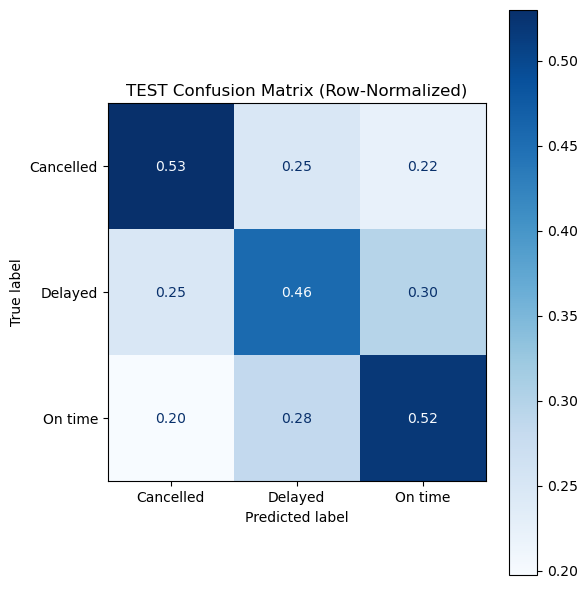

In [30]:
# === Visualize Confusion Matrix (Normalized) ===
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Choose split: "VAL" or "TEST"
SPLIT = "TEST"  

if SPLIT == "VAL":
    X_plot, y_true = X_val, val_lr[TARGET]
else:
    X_plot, y_true = X_test, test_lr[TARGET]

y_pred = lr_pipeline.predict(X_plot)

labels = lr_pipeline.named_steps["lr"].classes_

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=True)
ax.set_title(f"{SPLIT} Confusion Matrix (Row-Normalized)")
plt.tight_layout()
plt.show()

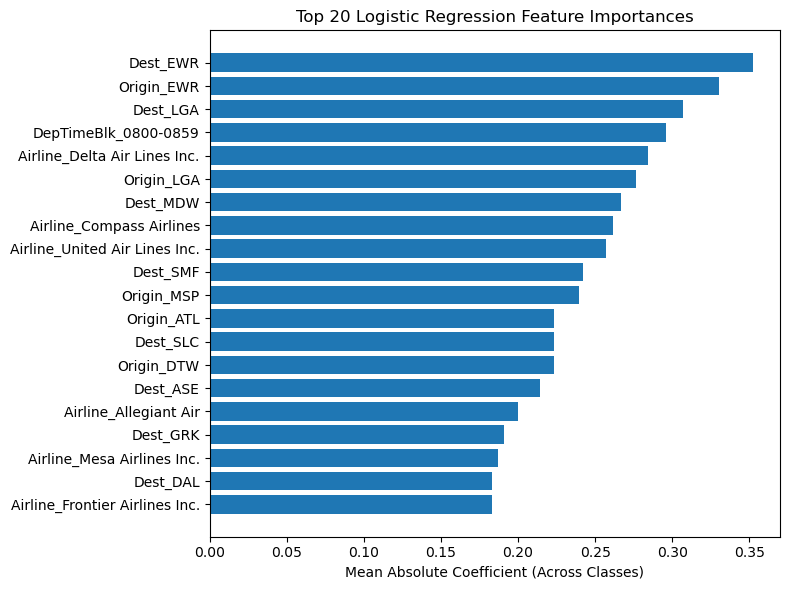

In [31]:
# === Logistic Regression Feature Importance ===
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get trained LR model
lr = lr_pipeline.named_steps["lr"]
preprocess = lr_pipeline.named_steps["preprocess"]

# Get feature names after preprocessing
feature_names = preprocess.get_feature_names_out()

# Coefficients shape: (n_classes, n_features)
coefs = lr.coef_

# Aggregate absolute importance across classes
importance = np.mean(np.abs(coefs), axis=0)

feat_imp = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

# Clean feature names for readability
feat_imp["feature"] = (
    feat_imp["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Logistic Regression Feature Importances")
plt.xlabel("Mean Absolute Coefficient (Across Classes)")
plt.tight_layout()
plt.show()